Throughout this lesson, you've been trying different models on the same two datasets, wine and diabetes. Now, we're going to try our hand at accelerating this methodology by using AutoGluon. In this exercise, train two different AutonGluon models and see how they compare to previous iterations in exercise 1 and 2.

You're tasked with completing the following steps:
1. Load in the wine dataset from scikit learn.
2. For the wine dataset, create a train and test split, 80% train / 20% test.
3. Create a AutoGluon Classifier model with these hyper parameters:
    1. time_limit: 120
    2. presets: best_quality
4. Output the model table summary
5. Evaluate the trained model on the test dataset
6. Load the diabetes dataset from scikit learn
7. For the Diabetes dataset, create a train and test split, 80% train / 20% test.
8. Create a AutoGluon Regression model with these hyper parameters:
    1. eval_metric: r2
    2. time_limit: 120
    3. presets: best_quality
9. Output the model table summary
10. Evaluate the trained model on the test dataset

## Setup

### Open up Sagemaker Studio

1. Notebook should be using a `ml.t3.medium` instance (2 vCPU + 4 GiB)
2. Notebook should be using kernal: `Python 3 (MXNet 1.8 Python 3.7 CPU Optimized)`

In [1]:
!pip install -U pip
!pip install -U setuptools wheel
!pip install -U "mxnet<2.0.0" bokeh==2.0.1
!pip install autogluon --no-cache-dir

  Using cached mxnet-1.9.1-py3-none-manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached bokeh-2.0.1.tar.gz (8.6 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [35 lines of output]
      /tmp/pip-install-7zcp3407/bokeh_997022a5340c4352b35ce05e1531fae9/versioneer.py:559: SyntaxWarning: invalid escape sequence '\s'
        mo = re.search(r'=\s*"(.*)"', line)
      Traceback (most recent call last):
        File "/opt/conda/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/opt/conda/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularDataset, TabularPredictor

## AutoGluon Classifier

In [3]:
# Load in the wine dataset
wine = datasets.load_wine()

In [4]:
# Create the wine `data` dataset as a dataframe and name the columns with `feature_names`
df = pd.DataFrame(wine["data"], columns=wine["feature_names"])

# Include the target as well
df['target'] = wine["target"]

In [5]:
# Split your data with these ratios: train: 0.8 | test: 0.2
df_train, df_test = train_test_split(df, test_size=0.2, random_state=0)

In [6]:
# How does the model perform on the training dataset and default model parameters?
# Using the hyperparameters in the requirements, is there improvement?
# Remember we use the test dataset to score the model
# No need to explicitly say this is a classifier, autogluon will pick it up
# predictor = TabularPredictor(label="target").fit(df, time_limit=120, presets="best_quality")  didn't work with the current resources
predictor = TabularPredictor(label="target").fit(df, time_limit=120, presets="medium_quality", dynamic_stacking=False)

No path specified. Models will be saved in: "AutogluonModels/ag-20260923_161556"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Tue Aug 25 15:42:53 UTC 2026
CPU Count:          2
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
Memory Avail:       2.16 GB / 3.74 GB (57.6%)
Disk Space Avail:   4.75 GB / 4.94 GB (96.1%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "/home/sagemaker-user/nd189-1-Introduction-to-Machine-Learning/algorithms-and-tools/concept3_autogluon/starter/AutogluonModels/ag-20260923_161556"
Train Data Rows:    178
Train Data Columns: 13
Label Column:

In [7]:
# Output the fit summary of the training run
predictor.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0            LightGBMXT   1.000000    accuracy       0.000674  0.336403                0.000674           0.336403            1       True          1
1              CatBoost   1.000000    accuracy       0.000695  1.054394                0.000695           1.054394            1       True          5
2         LightGBMLarge   1.000000    accuracy       0.000774  0.475460                0.000774           0.475460            1       True         10
3              LightGBM   1.000000    accuracy       0.000784  0.287979                0.000784           0.287979            1       True          2
4        NeuralNetTorch   1.000000    accuracy       0.006890  1.206877                0.006890           1.206877            1       True          9
5   WeightedEnsemble_L2   1.000000    

{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestGini': 'RFModel',
  'RandomForestEntr': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesGini': 'XTModel',
  'ExtraTreesEntr': 'XTModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': 1.0,
  'LightGBM': 1.0,
  'RandomForestGini': 1.0,
  'RandomForestEntr': 1.0,
  'CatBoost': 1.0,
  'ExtraTreesGini': 1.0,
  'ExtraTreesEntr': 1.0,
  'XGBoost': 0.9722222222222222,
  'NeuralNetTorch': 1.0,
  'LightGBMLarge': 1.0,
  'WeightedEnsemble_L2': 1.0},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT'],
  'LightGBM': ['LightGBM'],
  'RandomForestGini': ['RandomForestGini'],
  'RandomForestEntr': ['RandomForestEntr'],
  'CatBoost': ['CatBoost'],
  'ExtraTreesGini': ['ExtraTreesGini'],
  'ExtraTreesEntr': ['ExtraTreesEntr'],
  'XG

<Axes: xlabel='model'>

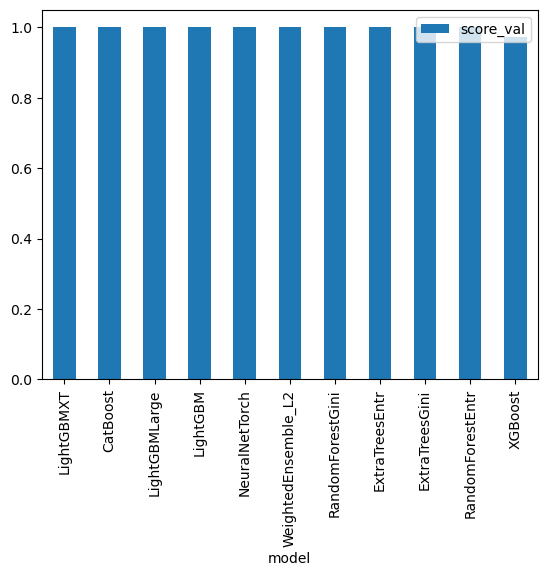

In [8]:
predictor.leaderboard(silent=True).plot(kind="bar", x="model", y="score_val")

In [9]:
# Evaluate the models performance on the test dataset

performance = predictor.evaluate(df_test)  # or the line code below. Both work.
# performance = predictor.evaluate_predictions(y_true=df_test["target"], y_pred=predictor.predict(df_test[wine["feature_names"]]))
performance


{'accuracy': 1.0, 'balanced_accuracy': 1.0, 'mcc': 1.0}

## AutoGluon Regression

In [10]:
# Load in the diabetes dataset
diabetes = datasets.load_diabetes()

In [11]:
# Create the diabetes `data` dataset as a dataframe and name the columns with `feature_names`
dfd = pd.DataFrame(diabetes["data"], columns=diabetes["feature_names"])

# Include the target as well
dfd['target'] = diabetes["target"]

In [12]:
# Split your data with these ratios: train: 0.8 | test: 0.2
dfd_train, dfd_test = train_test_split(dfd, test_size=0.2)

In [13]:
# How does the model perform on the training dataset and default model parameters?
# Using the hyperparameters in the requirements, is there improvement?
# Remember we use the test dataset to score the model
# No need to explicitly say this is a regression, autogluon will pick it up
predictor = TabularPredictor(label="target", problem_type="regression", eval_metric="r2").fit(dfd_train, time_limit=120, presets="medium_quality", dynamic_stacking=False)

No path specified. Models will be saved in: "AutogluonModels/ag-20260923_161932"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Tue Aug 25 15:42:53 UTC 2026
CPU Count:          2
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
Memory Avail:       1.93 GB / 3.74 GB (51.6%)
Disk Space Avail:   4.74 GB / 4.94 GB (96.0%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "/home/sagemaker-user/nd189-1-Introduction-to-Machine-Learning/algorithms-and-tools/concept3_autogluon/starter/AutogluonModels/ag-20260923_161932"
Train Data Rows:    353
Train Data Columns: 10
Label Column:

In [14]:
# Output the fit summary of the training run
predictor.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                 model  score_val eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2   0.614327          r2       0.093019  2.444788                0.000772           0.078653            2       True          9
1       NeuralNetTorch   0.603349          r2       0.004278  0.743400                0.004278           0.743400            1       True          7
2           LightGBMXT   0.583176          r2       0.001169  0.883788                0.001169           0.883788            1       True          1
3             CatBoost   0.567926          r2       0.001055  0.547670                0.001055           0.547670            1       True          4
4      RandomForestMSE   0.561645          r2       0.086799  0.738948                0.086799           0.738948            1       True          3
5        ExtraTreesMSE   0.555413          r

{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestMSE': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesMSE': 'XTModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': 0.5831761657229814,
  'LightGBM': 0.5471894671090947,
  'RandomForestMSE': 0.5616454425903654,
  'CatBoost': 0.567926066271628,
  'ExtraTreesMSE': 0.5554131964327055,
  'XGBoost': 0.5197449922161701,
  'NeuralNetTorch': 0.6033487267487644,
  'LightGBMLarge': 0.4523939490628963,
  'WeightedEnsemble_L2': 0.6143272048171102},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT'],
  'LightGBM': ['LightGBM'],
  'RandomForestMSE': ['RandomForestMSE'],
  'CatBoost': ['CatBoost'],
  'ExtraTreesMSE': ['ExtraTreesMSE'],
  'XGBoost': ['XGBoost'],
  'NeuralNetTorch': ['NeuralNetTorch'],
  'LightGBMLarge': ['LightGB

<Axes: xlabel='model'>

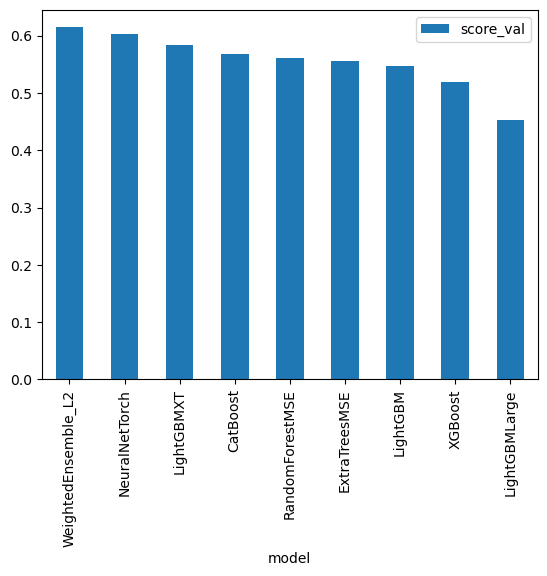

In [18]:
predictor.leaderboard(silent=True).plot(kind="bar", x="model", y="score_val")

In [19]:
# Evaluate the models performance on the test dataset
performance = predictor.evaluate(dfd_test)  # The code in the line below works too
# performance = predictor.evaluate_predictions(y_true=dfd_test["target"], y_pred=predictor.predict(dfd_test[diabetes["feature_names"]]))
performance

{'r2': 0.3646192023311816,
 'root_mean_squared_error': -64.7771216032532,
 'mean_squared_error': -4196.075483202654,
 'mean_absolute_error': -52.68578021445971,
 'pearsonr': 0.6206425927566218,
 'median_absolute_error': -45.39007568359375}